In [33]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
tickers = ['AAPL', 'MSFT', 'GOOGL']
start_date = '2020-01-01'
end_date = '2024-01-01'

data = yf.download(tickers, start=start_date, end=end_date)['Close']

daily_returns = data.pct_change().dropna()

annual_returns = daily_returns.mean() * 252

cov_matrix = daily_returns.cov() * 252

risk_free_rate = 0.04

C:\Users\pablo\AppData\Local\Temp\ipykernel_36148\2585162612.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed


In [35]:
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

np.random.seed(42)

for i in range(num_portfolios):
    # Generar pesos aleatorios y normalizarlos para que sumen 1
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Rendimiento esperado del portafolio
    portfolio_return = np.sum(weights * annual_returns)
    
    # Riesgo (Volatilidad o Desviación Estándar) del portafolio
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Ratio de Sharpe
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev
    
    # Guardar resultados
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = sharpe_ratio

In [36]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_ret = results[0, max_sharpe_idx]
max_sharpe_vol = results[1, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

min_vol_idx = np.argmin(results[1])
min_vol_ret = results[0, min_vol_idx]
min_vol_vol = results[1, min_vol_idx]
min_vol_weights = weights_record[min_vol_idx]

# Portafolio de Mayor Rendimiento
max_ret_idx = np.argmax(results[0])
max_ret_ret = results[0, max_ret_idx]
max_ret_vol = results[1, max_ret_idx]
max_ret_weights = weights_record[max_ret_idx]

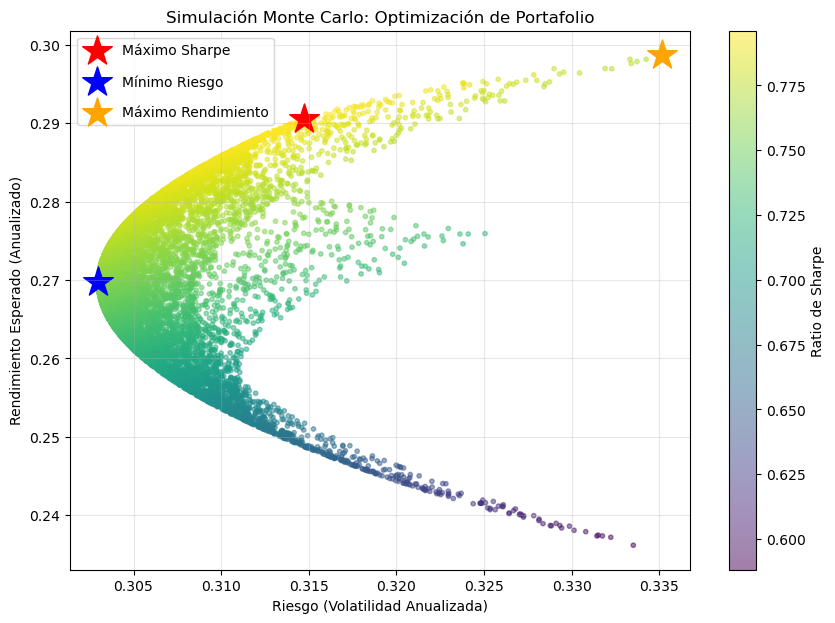

--------------------------------------------------
PORTAFOLIO DE MÁXIMO SHARPE:
Rendimiento: 29.06%
Riesgo: 31.48%
Ratio Sharpe: 0.80
Peso AAPL: 63.82%
Peso MSFT: 0.15%
Peso GOOGL: 36.03%

--------------------------------------------------
PORTAFOLIO DE MÍNIMO RIESGO:
Rendimiento: 26.98%
Riesgo: 30.30%
Peso AAPL: 33.48%
Peso MSFT: 33.96%
Peso GOOGL: 32.57%

--------------------------------------------------
PORTAFOLIO DE MÁXIMO RENDIMIENTO:
Rendimiento: 29.87%
Riesgo: 33.52%
Peso AAPL: 99.48%
Peso MSFT: 0.48%
Peso GOOGL: 0.04%


In [37]:
# 5. Graficar la frontera eficiente y los portafolios clave
plt.figure(figsize=(10, 7))
# Graficar todos los portafolios simulados usando el Sharpe Ratio como color
scatter = plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(scatter, label='Ratio de Sharpe')

# Marcar el portafolio de Máximo Sharpe (Estrella Roja)
plt.scatter(max_sharpe_vol, max_sharpe_ret, marker='*', color='r', s=500, label='Máximo Sharpe')

# Marcar el portafolio de Mínima Volatilidad (Estrella Azul)
plt.scatter(min_vol_vol, min_vol_ret, marker='*', color='b', s=500, label='Mínimo Riesgo')

# Marcar el portafolio de Máximo Rendimiento (Estrella Naranja)
plt.scatter(max_ret_vol, max_ret_ret, marker='*', color='orange', s=500, label='Máximo Rendimiento')

plt.title('Simulación Monte Carlo: Optimización de Portafolio')
plt.xlabel('Riesgo (Volatilidad Anualizada)')
plt.ylabel('Rendimiento Esperado (Anualizado)')
plt.legend(labelspacing=1.2)
plt.grid(True, alpha=0.3)
plt.show()

# Imprimir información de los portafolios
print("-" * 50)
print("PORTAFOLIO DE MÁXIMO SHARPE:")
print(f"Rendimiento: {max_sharpe_ret:.2%}")
print(f"Riesgo: {max_sharpe_vol:.2%}")
print(f"Ratio Sharpe: {results[2, max_sharpe_idx]:.2f}")
for i, ticker in enumerate(tickers):
    print(f"Peso {ticker}: {max_sharpe_weights[i]:.2%}")

print("\n" + "-" * 50)
print("PORTAFOLIO DE MÍNIMO RIESGO:")
print(f"Rendimiento: {min_vol_ret:.2%}")
print(f"Riesgo: {min_vol_vol:.2%}")
for i, ticker in enumerate(tickers):
    print(f"Peso {ticker}: {min_vol_weights[i]:.2%}")

print("\n" + "-" * 50)
print("PORTAFOLIO DE MÁXIMO RENDIMIENTO:")
print(f"Rendimiento: {max_ret_ret:.2%}")
print(f"Riesgo: {max_ret_vol:.2%}")
for i, ticker in enumerate(tickers):
    print(f"Peso {ticker}: {max_ret_weights[i]:.2%}")

### Análisis y Recomendación de Portafolio

1. **Portafolio de Menor Riesgo (Mínima Volatilidad - Estrella Azul):** Es ideal para un inversionista altamente conservador. Se concentra fuertemente en el activo que históricamente haya mostrado menores fluctuaciones conjuntas con los demás, sacrificando una parte importante del rendimiento esperado para garantizar la mayor estabilidad posible.
2. **Portafolio de Mayor Rendimiento (Estrella Naranja):** Se sitúa en la punta derecha superior de la gráfica y está compuesto prácticamente al 100% por el activo más rentable del periodo analizado. Tiene un riesgo y una volatilidad extremos, careciendo de los beneficios reales de la diversificación.
3. **Portafolio de Máximo Ratio de Sharpe (Estrella Roja):** Este portafolio encuentra el equilibrio óptimo matemáticamente hablando. Maximiza el exceso de retorno obtenido por cada unidad adicional de riesgo asumido sobre la tasa libre de riesgo (4%).

**¿Qué portafolio recomendaría y por qué?**

Recomiendo el portafolio con el Mayor Ratio de Sharpe (Estrella Roja).
Lo recomiendo porque es el que mejor aprovecha en riesgo que se asume para conseguir la mejor rentabilidad. (Más alto ratio de sharpe)